In [3]:
%cd /home/maia-user/NeuroCBIR/

/home/maia-user/NeuroCBIR


**FIGURE: EXAMPLE OF RESULT - GT FOR WHOLE BRAIN**

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/home/maia-user/cifs/Datasets/"


In [5]:
# Load metadata
import pandas as pd
import os

# Your existing list of DataFrames
clinical_ds = [
    pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
]

# Combine into a single DataFrame
clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# (Optional) check shape and columns
print(clinical_ds.shape)
print(clinical_ds.columns)

(26693, 19)
Index(['GUID', 'project', 'subject', 'timepoint', 'repet', 'scan_type',
       'field_strength', 'manufacturer', 'model_name', 'disease', 'age',
       'brain', 'seg', 'brain_qc', 'useable', 'sex', 'acq_date', 'raw',
       'mutual_information'],
      dtype='object')


In [6]:
retrival_res = pd.read_csv("data/results/whole_brain/eval_cl64/retrieval.csv")
retrival_res = retrival_res.rename(columns={"query": "GUID"})
metadata = pd.merge(clinical_ds, retrival_res, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")
metadata.tail()

METADATA: Original rows: 23652


,GUID,project,subject,timepoint,repet,scan_type,field_strength,manufacturer,model_name,disease,...,useable,sex,acq_date,raw,mutual_information,top1,top2,top3,top4,top5
23647,OAS31470_MR_d0007,oasis3,OAS31470,7,1,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31470_MR_d0007/mri/orig/001.mgz,NaN,0ea18a7a-3497-46f1-948e-0d91f810a689,3709ec9b-347b-4370-9579-b45ca6a0c900,2cff1502-7f35-4bf8-9e01-dbb069e9d544,6909865e-ccb1-439f-94e1-7b0ec4e0f141,2f1763d2-5f13-46f0-9b0f-fd3cbbad1900
23648,OAS31471_MR_d0059,oasis3,OAS31471,59,1,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31471_MR_d0059/mri/orig/001.mgz,NaN,328fcc91-f725-46e7-96a7-4bb739200881,413f437b-ef33-40ae-9a21-a65a176caf81,0ac43bc0-f000-4564-928e-3288761685c4,0468173d-dcb9-4e1a-90bd-9c75b351d9d9,0edf9aa2-91ce-46e0-9022-34f4e7cd3210
23649,OAS31472_MR_d0045,oasis3,OAS31472,45,1,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31472_MR_d0045/mri/orig/001.mgz,NaN,4c186356-5fe1-44f1-99ce-1b51fc67bb49,3a87855c-6825-4e61-9aa0-1db79e689499,01e6d333-d907-4f18-9875-10bbb848fa61,3cdf4f91-5fef-4398-9f68-73d230cec810,047f7495-2969-4e64-9d31-67bb426eb010
23650,OAS31473_MR_d0136,oasis3,OAS31473,136,1,T1,3.0,SIEMENS,Biograph_mMR,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31473_MR_d0136/mri/orig/001.mgz,NaN,OAS30960_MR_d4513,OAS30960_MR_d3518,OAS30960_MR_d5864,39f6d31b-39ab-4014-964d-972539fe2a90,OAS30960_MR_d3686
23651,OAS31474_MR_d0150,oasis3,OAS31474,150,1,T1,3.0,SIEMENS,Biograph_mMR,AD,...,1,NaN,NaN,OASIS3/oasis3/OAS31474_MR_d0150/mri/orig/001.mgz,NaN,5cb0656a-9d1e-4636-91ae-882316825579,OAS30448_MR_d0101,88e057b4-ef9b-42b3-9dca-4f78f3d95c09,0e36170e-efd7-4e80-9738-4f90da07be40,4b3100cc-5ceb-4cda-96d3-0715026ac5a4


In [7]:
metadata.query("project == 'oasis3'")


,GUID,project,subject,timepoint,repet,scan_type,field_strength,manufacturer,model_name,disease,...,useable,sex,acq_date,raw,mutual_information,top1,top2,top3,top4,top5
20971,OAS30001_MR_d0129,oasis3,OAS30001,129,1,T1,3.0,SIEMENS,TrioTim,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0129/mri/orig/001.mgz,NaN,OAS30001_MR_d0757,OAS30001_MR_d3132,OAS30001_MR_d4467,OAS30001_MR_d3746,OAS30001_MR_d2430
20972,OAS30001_MR_d0757,oasis3,OAS30001,757,1,T1,3.0,SIEMENS,TrioTim,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0757/mri/orig/001.mgz,NaN,OAS30001_MR_d0129,OAS30001_MR_d3132,OAS30001_MR_d3746,OAS30001_MR_d4467,OAS30001_MR_d2430
20973,OAS30001_MR_d2430,oasis3,OAS30001,2430,1,T1,3.0,SIEMENS,Biograph_mMR,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d2430/mri/orig/001.mgz,NaN,OAS30001_MR_d4467,OAS30001_MR_d3746,OAS30001_MR_d3132,OAS30001_MR_d0129,OAS30001_MR_d0757
20974,OAS30001_MR_d3132,oasis3,OAS30001,3132,1,T1,3.0,SIEMENS,TrioTim,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3132/mri/orig/001.mgz,NaN,OAS30001_MR_d0129,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d3746,OAS30001_MR_d2430
20975,OAS30001_MR_d3746,oasis3,OAS30001,3746,1,T1,3.0,SIEMENS,Biograph_mMR,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3746/mri/orig/001.mgz,NaN,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d2430,OAS30001_MR_d0757,OAS30001_MR_d0129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23647,OAS31470_MR_d0007,oasis3,OAS31470,7,1,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31470_MR_d0007/mri/orig/001.mgz,NaN,0ea18a7a-3497-46f1-948e-0d91f810a689,3709ec9b-347b-4370-9579-b45ca6a0c900,2cff1502-7f35-4bf8-9e01-dbb069e9d544,6909865e-ccb1-439f-94e1-7b0ec4e0f141,2f1763d2-5f13-46f0-9b0f-fd3cbbad1900
23648,OAS31471_MR_d0059,oasis3,OAS31471,59,1,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31471_MR_d0059/mri/orig/001.mgz,NaN,328fcc91-f725-46e7-96a7-4bb739200881,413f437b-ef33-40ae-9a21-a65a176caf81,0ac43bc0-f000-4564-928e-3288761685c4,0468173d-dcb9-4e1a-90bd-9c75b351d9d9,0edf9aa2-91ce-46e0-9022-34f4e7cd3210
23649,OAS31472_MR_d0045,oasis3,OAS31472,45,1,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31472_MR_d0045/mri/orig/001.mgz,NaN,4c186356-5fe1-44f1-99ce-1b51fc67bb49,3a87855c-6825-4e61-9aa0-1db79e689499,01e6d333-d907-4f18-9875-10bbb848fa61,3cdf4f91-5fef-4398-9f68-73d230cec810,047f7495-2969-4e64-9d31-67bb426eb010
23650,OAS31473_MR_d0136,oasis3,OAS31473,136,1,T1,3.0,SIEMENS,Biograph_mMR,CN,...,1,NaN,NaN,OASIS3/oasis3/OAS31473_MR_d0136/mri/orig/001.mgz,NaN,OAS30960_MR_d4513,OAS30960_MR_d3518,OAS30960_MR_d5864,39f6d31b-39ab-4014-964d-972539fe2a90,OAS30960_MR_d3686


(A) Query: OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(B) 0ea18a7a-3497-46f1-948e-0d91f810a689 - adni
(C) 3709ec9b-347b-4370-9579-b45ca6a0c900 - adni
(D) 2cff1502-7f35-4bf8-9e01-dbb069e9d544 - adni
(E) 6909865e-ccb1-439f-94e1-7b0ec4e0f141 - adni
(F) 2f1763d2-5f13-46f0-9b0f-fd3cbbad1900 - adni


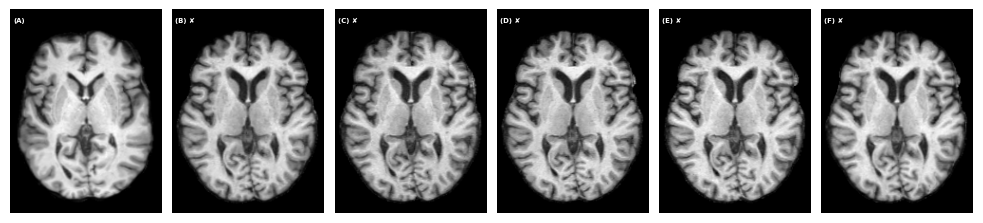

In [11]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_brain_slices(brains, titles, slice_index=None, axes=None, top_pad=7):
    """Plot middle slice (or given slice) of each brain in a row with top padding."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        idx = slice_index or brain.shape[1] // 2  
        slice_img = brain[:, idx, : ].T

        # add top padding (rows of zeros)
        slice_img_padded = np.pad(slice_img, ((0, top_pad), (0, 0)), mode='constant', constant_values=0)

        axes[i].imshow(slice_img_padded, cmap="gray", origin="lower")
        axes[i].axis("off")

        axes[i].text(
            0.02, 0.96, 
            title,
            horizontalalignment='left', 
            verticalalignment='top', 
            transform=axes[i].transAxes,
            color='w', fontsize=5, fontweight="bold"
        )


        
# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, 6, figsize=(25*cm,10*cm))

# Example usage:
query_guid = "OAS31470_MR_d0007"  # pick one from your metadata
row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [row["brain"]]
titles = ["(A)"]


title_caps = ["(B)", "(C)", "(D)", "(E)", "(F)"]
for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
    paths.append(match_row["brain"])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
brains = [load_nifti(p, DATA_PATH) for p in paths]

# Plot mid-slices
plot_brain_slices(brains, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.show()




(A.1): OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(A.2) OAS30001_MR_d0757 - oasis3
(A.3) OAS30001_MR_d3132 - oasis3
(A.4) OAS30001_MR_d4467 - oasis3
(A.5) OAS30001_MR_d3746 - oasis3
(A.6) OAS30001_MR_d2430 - oasis3
(B.1): OAS30052_MR_d1296 from subject OAS30052 with a total of 5.
Other scans:
(B.2) OAS30052_MR_d0693 - oasis3
(B.3) OAS30052_MR_d4235 - oasis3
(B.4) OAS30052_MR_d2709 - oasis3
(B.5) OAS30052_MR_d2737 - oasis3
(B.6) 315af748-21cf-453b-9f1d-71703bb06649 - adni
(C.1): OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(C.2) 0ea18a7a-3497-46f1-948e-0d91f810a689 - adni
(C.3) 3709ec9b-347b-4370-9579-b45ca6a0c900 - adni
(C.4) 2cff1502-7f35-4bf8-9e01-dbb069e9d544 - adni
(C.5) 6909865e-ccb1-439f-94e1-7b0ec4e0f141 - adni
(C.6) 2f1763d2-5f13-46f0-9b0f-fd3cbbad1900 - adni


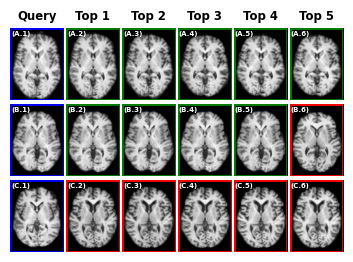

In [9]:
import matplotlib.patches as patches

queries_guid = ["OAS30001_MR_d0129", "OAS30052_MR_d1296", "OAS31470_MR_d0007"]
title_capss = [["(A.1)", "(A.2)", "(A.3)", "(A.4)", "(A.5)", "(A.6)"],
               ["(B.1)", "(B.2)", "(B.3)", "(B.4)", "(B.5)", "(B.6)"],
               ["(C.1)", "(C.2)", "(C.3)", "(C.4)", "(C.5)", "(C.6)"]]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, 6, figsize=(9*cm, 6.7*cm))#, figsize=(18*cm, n_queries*4.1*cm))

for axes, query_guid, title_caps in zip(axess, queries_guid, title_capss):
# axes = axess[0]

    # Example usage:
    row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [row["brain"]]
    titles = [title_caps[0]]
    labels = []  # will store hit/fail info

    title_caps = title_caps[1:]
    for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append(match_row["brain"])
        is_hit = match_row["subject"] == query_subject
        labels.append(is_hit)
        # titles.append(f"{title_caps[i]} {'✔' if is_hit else '✘'}")
        titles.append(f"{title_caps[i]}")

    # Load brain volumes
    brains = [load_nifti(p, DATA_PATH) for p in paths]

    # Plot mid-slices
    plot_brain_slices(brains, titles, axes=axes)
    
    # --- Add borders ---
    for j, ax in enumerate(axes):
        # query
        if j == 0:
            color = "blue"
        else:
            color = "green" if labels[j-1] else "red"

        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")

axess[0][0].set_title("Query", fontweight="bold")
axess[0][1].set_title("Top 1", fontweight="bold")
axess[0][2].set_title("Top 2", fontweight="bold")
axess[0][3].set_title("Top 3", fontweight="bold")
axess[0][4].set_title("Top 4", fontweight="bold")
axess[0][5].set_title("Top 5", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(wspace=+0.04, hspace=0)

# plt.savefig(f"figures/example_brain_retrieval.pdf", format='pdf', 
# dpi=600,  # increase for higher-resolution embedded images
# bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
halt

NameError: name 'halt' is not defined

**FIGURE: EXAMPLE OF RESULT - GT FOR BRAIN REGION**

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/home/maia-user/cifs/Datasets/"


In [ ]:
# Load metadata
import pandas as pd
import os

# Your existing list of DataFrames
clinical_ds = [
    pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
]

# Combine into a single DataFrame
clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# (Optional) check shape and columns
print(clinical_ds.shape)
print(clinical_ds.columns)

(26693, 15)
Index(['GUID', 'project', 'subject', 'timepoint', 'scan_type',
       'field_strength', 'manufacturer', 'model_name', 'disease', 'age',
       'brain', 'sex', 'acq_date', 'raw', 'seg'],
      dtype='object')


In [ ]:
retrival_res = pd.read_csv("data/results/region_brain/eval_cl32/retrieval_all.csv")
retrival_res = retrival_res.rename(columns={"query": "GUID"})
metadata = pd.merge(clinical_ds, retrival_res, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")
struct_name = "Right-Hippocampus"
metadata = metadata.query(f"LabelName == '{struct_name}'")
print(f"METADATA: after filering rows: {len(metadata)}")


METADATA: Original rows: 2857351
METADATA: after filering rows: 26176


In [ ]:
metadata.query("project == 'oasis3'")

,GUID,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age,...,sex,acq_date,raw,seg,top1,top2,top3,top4,top5,LabelName
2268107,OAS30001_MR_d0129,oasis3,OAS30001,129,T1,3.0,SIEMENS,TrioTim,CN,65.5,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0129/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0129/mri/align_apar...,OAS30001_MR_d0757,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d2430,OAS30001_MR_d3746,Right-Hippocampus
2268219,OAS30001_MR_d0757,oasis3,OAS30001,757,T1,3.0,SIEMENS,TrioTim,CN,67.3,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0757/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0757/mri/align_apar...,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d0129,OAS30001_MR_d2430,OAS30001_MR_d3746,Right-Hippocampus
2268331,OAS30001_MR_d2430,oasis3,OAS30001,2430,T1,3.0,SIEMENS,Biograph_mMR,CN,71.8,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d2430/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d2430/mri/align_apar...,OAS30001_MR_d3746,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d3132,OAS30001_MR_d0129,Right-Hippocampus
2268443,OAS30001_MR_d3132,oasis3,OAS30001,3132,T1,3.0,SIEMENS,TrioTim,CN,73.8,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3132/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3132/mri/align_apar...,OAS30001_MR_d0757,OAS30001_MR_d4467,OAS30001_MR_d3746,OAS30001_MR_d0129,OAS30001_MR_d2430,Right-Hippocampus
2268555,OAS30001_MR_d3746,oasis3,OAS30001,3746,T1,3.0,SIEMENS,Biograph_mMR,CN,75.5,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3746/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3746/mri/align_apar...,OAS30001_MR_d2430,OAS30001_MR_d3132,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d0129,Right-Hippocampus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2568667,OAS31470_MR_d0007,oasis3,OAS31470,7,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,64.9,...,NaN,NaN,OASIS3/oasis3/OAS31470_MR_d0007/mri/orig/001.mgz,OASIS3/oasis3/OAS31470_MR_d0007/mri/align_apar...,slim_25762_2,slim_25794_1,slim_30980_1,slim_30883_1,slim_30828_1,Right-Hippocampus
2568779,OAS31471_MR_d0059,oasis3,OAS31471,59,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,65.5,...,NaN,NaN,OASIS3/oasis3/OAS31471_MR_d0059/mri/orig/001.mgz,OASIS3/oasis3/OAS31471_MR_d0059/mri/align_apar...,2a24aaca-69ae-4dbc-9591-1eb6c7c531d9,610f4df2-e22f-4b2a-9849-5e466bdcc424,I472743,9a356541-1b93-49d2-9c1d-55fcf2ddd904,OAS31323_MR_d0123,Right-Hippocampus
2568892,OAS31472_MR_d0045,oasis3,OAS31472,45,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,67.4,...,NaN,NaN,OASIS3/oasis3/OAS31472_MR_d0045/mri/orig/001.mgz,OASIS3/oasis3/OAS31472_MR_d0045/mri/align_apar...,slim_30753_3,slim_30753_1,OAS31016_MR_d0126,03195db1-70ec-4556-90d2-1477d7f7b764,0b5b00cd-4698-4670-90c9-7f79900aae40,Right-Hippocampus
2569005,OAS31473_MR_d0136,oasis3,OAS31473,136,T1,3.0,SIEMENS,Biograph_mMR,CN,57.0,...,NaN,NaN,OASIS3/oasis3/OAS31473_MR_d0136/mri/orig/001.mgz,OASIS3/oasis3/OAS31473_MR_d0136/mri/align_apar...,OAS30595_MR_d0848,OAS30595_MR_d0084,OAS31311_MR_d0055,558d6564-0369-4450-9d7e-96dfd19b6640,3a1cb653-0fa4-42c0-916b-92d06a435190,Right-Hippocampus


In [ ]:
# Load labels and bounding boxes for cortical/subcortical structures
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column

(A) Query: OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(B) OAS30001_MR_d0757 - oasis3
(C) OAS30001_MR_d4467 - oasis3
(D) OAS30001_MR_d3132 - oasis3
(E) OAS30001_MR_d2430 - oasis3
(F) OAS30001_MR_d3746 - oasis3


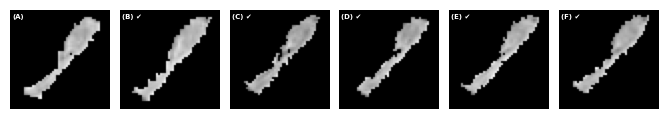

In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_struct_slices(brains, titles, slice_index=None, axes=None):
    """Plot middle slice (or given slice) of each brain in a row."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        idx = slice_index or brain.shape[0] // 2  
        axes[i].imshow(brain[idx, :, : ].T, cmap="gray", origin="lower")
        # axes[i].set_title(title, y=0.9, x=0.35, va="top", color='w') #, fontsize=8)
        axes[i].axis("off")
        axes[i].text(0.02, 0.96, title, horizontalalignment='left', 
                     verticalalignment='top', transform=axes[i].transAxes, color='w', fontsize=5, fontweight="bold")
        
def obtain_struct(brain_path, seg_path, DATA_PATH, target_struct_name, labels_bb_df):
    image = load_nifti(brain_path, DATA_PATH).astype(np.float32)
    seg = load_nifti(seg_path, DATA_PATH)

    # Filter the label row for the selected structure
    struct_row_df = labels_bb_df.query(f"LabelName == '{target_struct_name}' and Use == 1").reset_index(drop=True)
    if len(struct_row_df) == 0:
        raise ValueError(f"Structure '{target_struct_name}' not found in labels_bb_df with Use == 1.")
    struct_row = struct_row_df.iloc[0]
    struct_map_id = struct_row["LabelID"]

    # Bounding box
    x1, x2 = int(struct_row["min_x"]) - 5, int(struct_row["max_x"]) + 5
    y1, y2 = int(struct_row["min_y"]) - 5, int(struct_row["max_y"]) + 5
    z1, z2 = int(struct_row["min_z"]) - 5, int(struct_row["max_z"]) + 5

    # Preprocess all samples
    patch_brain = image[x1:x2, y1:y2, z1:z2]
    patch_seg = (seg[x1:x2, y1:y2, z1:z2] == struct_map_id)

    struct = patch_brain * patch_seg
    
    return struct

        
# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, 6, figsize=(17*cm, 5*cm))

# Example usage:
query_guid = "OAS30001_MR_d0129"  # pick one from your metadata
row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [[row["brain"], row["seg"]]]
titles = ["(A)"]

title_caps = ["(B)", "(C)", "(D)", "(E)", "(F)"]
for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
    paths.append([match_row["brain"], match_row["seg"]])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

# Plot mid-slices
plot_struct_slices(structs, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.show()

(A.1): OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(A.2) OAS30001_MR_d0757 - oasis3
(A.3) OAS30001_MR_d4467 - oasis3
(A.4) OAS30001_MR_d3132 - oasis3
(A.5) OAS30001_MR_d2430 - oasis3
(A.6) OAS30001_MR_d3746 - oasis3
(B.1): OAS30052_MR_d1296 from subject OAS30052 with a total of 5.
Other scans:
(B.2) OAS30052_MR_d2709 - oasis3
(B.3) OAS30052_MR_d2737 - oasis3
(B.4) OAS30052_MR_d0693 - oasis3
(B.5) OAS30052_MR_d4235 - oasis3
(B.6) OAS30284_MR_d1633 - oasis3
(C.1): OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(C.2) slim_25762_2 - slim
(C.3) slim_25794_1 - slim
(C.4) slim_30980_1 - slim
(C.5) slim_30883_1 - slim
(C.6) slim_30828_1 - slim


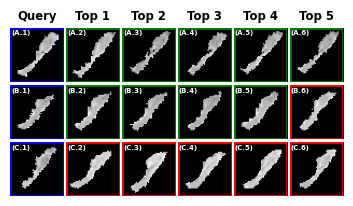

In [ ]:
import matplotlib.patches as patches

queries_guid = ["OAS30001_MR_d0129", "OAS30052_MR_d1296", "OAS31470_MR_d0007"]
title_capss = [["(A.1)", "(A.2)", "(A.3)", "(A.4)", "(A.5)", "(A.6)"],
               ["(B.1)", "(B.2)", "(B.3)", "(B.4)", "(B.5)", "(B.6)"],
               ["(C.1)", "(C.2)", "(C.3)", "(C.4)", "(C.5)", "(C.6)"]]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, 6, figsize=(9*cm, 5.25*cm))#, figsize=(18*cm, n_queries*4.1*cm))

for axes, query_guid, title_caps in zip(axess, queries_guid, title_capss):
# axes = axess[0]

    # Example usage:
    row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [[row["brain"], row["seg"]]]
    titles = [title_caps[0]]
    labels=[]

    title_caps = title_caps[1:]
    for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append([match_row["brain"], match_row["seg"]])
        is_hit = match_row["subject"] == query_subject
        labels.append(is_hit)
        # titles.append(f"{title_caps[i]} {'✔' if is_hit else '✘'}")
        titles.append(f"{title_caps[i]}")

    # Load brain volumes
    structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

    # Plot mid-slices
    plot_struct_slices(structs, titles, axes=axes)
    
    # --- Add borders ---
    for j, ax in enumerate(axes):
        # query
        if j == 0:
            color = "blue"
        else:
            color = "green" if labels[j-1] else "red"

        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")

axess[0][0].set_title("Query", fontweight="bold")
axess[0][1].set_title("Top 1", fontweight="bold")
axess[0][2].set_title("Top 2", fontweight="bold")
axess[0][3].set_title("Top 3", fontweight="bold")
axess[0][4].set_title("Top 4", fontweight="bold")
axess[0][5].set_title("Top 5", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(wspace=0.04, hspace=0)

plt.savefig(f"figures/example_struct_retrieval.pdf", format='pdf', 
dpi=600,  # increase for higher-resolution embedded images
bbox_inches='tight', pad_inches=0)
plt.show()

# plt.savefig(f"figures/example_struct_retrieval.pdf", format='pdf', bbox_inches='tight')
# plt.show()

## Whole-Brain retrieval based on multiple user-selected regions

In [1]:
%cd /home/maia-user/NeuroCBIR/

/home/maia-user/NeuroCBIR


In [2]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tqdm import tqdm
import logging

def retrieve_topk_for_queries(
    dataset: pd.DataFrame,
    queries: pd.DataFrame,
    top_k: int = 3,
    feature_column: str = "features",
    guid_column: str = "GUID"
) -> pd.DataFrame:
    """
    Retrieve the top-k most similar entries for a subset of queries, 
    using cosine similarity against the full dataset as the retrieval pool.

    Args:
        dataset (pd.DataFrame): Full pool of entries with features and GUIDs.
        queries (pd.DataFrame): Subset of rows from dataset to use as queries.
        top_k (int): Number of top similar entries to retrieve.
        feature_column (str): Column containing the feature vectors.
        guid_column (str): Column with unique scan identifiers (e.g., 'GUID').

    Returns:
        pd.DataFrame: Retrieval results. One row per query, first column is the query GUID,
                      followed by the GUIDs of the top-k retrieved entries.
    """
    if top_k == -1:
        top_k = len(dataset) - 1  # Exclude self if present
    
    # Retrieval pool
    features_matrix = np.stack(dataset[feature_column].values)
    guids = dataset[guid_column].values

    # Queries
    query_features = np.stack(queries[feature_column].values)
    query_guids = queries[guid_column].values

    retrievals = []
    for i in tqdm(range(len(queries)), desc="Retrieving"):
        similarities = cosine_similarity(query_features[i].reshape(1, -1), features_matrix)[0].astype(np.float32)
        
        # Exclude self if query is in the dataset and same subject
        subject_mask = (dataset["subject"] == queries.iloc[i]["subject"]).values
        similarities[subject_mask] = -1  # Zero out similarities for same subject
        # if query_guids[i] in guids:
        #     idx_self = np.where(guids == query_guids[i])[0]
        #     similarities[idx_self] = -1

        # Get top-k
        top_k_indices = np.argsort(similarities)[::-1][:top_k]
        row = [query_guids[i]] + guids[top_k_indices].tolist() + similarities[top_k_indices].tolist()
        retrievals.append(row)

    col_names = ["query"] + [f"top{i+1}" for i in range(top_k)] + [f"sim{i+1}" for i in range(top_k)]
    return pd.DataFrame(retrievals, columns=col_names)



In [ ]:
config = {
    "data_path": "/home/maia-user/cifs/Datasets/",
    "emb_dir": "data/results/region_brain/eval_cl32/",
    "output_dir": "data/explanability",
    "metadata_file_name": "combined_metadata.csv",
    "labels_path": "deploy/data/labels.csv",
    "bb_path": "data/bounding_boxes.csv",
    "embedding_file": "projected_embeddings.parquet",
    "project_filter": "",
    "class_column": "subject",
    "top_k_values": [
        -1
    ],
    # "struct_names": None, # <-- Set to None to compute all struct names
    # "struct_names": [ # <-- Set to None to compute all struct names
    #     "Left-Hippocampus",
    #     "Left-Thalamus",
    #     "Left-Amygdala",
    #     "Left-Lateral-Ventricle",
    #     "Right-Hippocampus",
    #     "Right-Thalamus",
    #     "Right-Amygdala",
    #     "Right-Lateral-Ventricle",
    # ]
    "struct_names_list": [ # <-- Set to None to compute all struct names
        [
            # "Left-Cerebral-White-Matter", "Right-Cerebral-White-Matter", 
            "Left-Lateral-Ventricle", #"Right-Lateral-Ventricle", 
            # "3rd-Ventricle",
            # "Left-Thalamus", "Right-Thalamus"
         ],
    ]
}

n_guids = 10




In [4]:
import os

# Load and filter metadata
clinical_ds = pd.read_csv(os.path.join(config["data_path"], config["metadata_file_name"]))

# Load real features from parquet
emb_path = os.path.join(config["emb_dir"], config["embedding_file"])  # e.g., "outputs/embeddings.parquet"
df_embs = pd.read_parquet(emb_path)


# Ensure GUID is string and joinable
df_embs["GUID"] = df_embs["GUID"].astype(str)
df_embs["LabelName"] = df_embs["LabelName"].astype(str)
clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

# Filter out unusable scans
clinical_ds = clinical_ds[clinical_ds["useable"] == 1].reset_index(drop=True)

# Only a scan per subject
clinical_ds = clinical_ds.sort_values(by=["subject", "GUID"]).drop_duplicates(subset=["subject"], keep="first").reset_index(drop=True)

# Merge on GUID
dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

# Convert embedding columns into a single 'features' column of vectors
embedding_cols = [col for col in df_embs.columns if not col in  ["GUID", "LabelName"]]
dataset["features"] = dataset[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)

# Pick random n_queries from dataset as queries
queries = dataset.sample(n=n_guids, random_state=42).reset_index(drop=True)
queries_guids = set(queries["GUID"].tolist())

all_metrics = {}
combined_retrievals = []

struct_names_list = config["struct_names_list"]

# Set a multi-index for fast lookup
ds = dataset.set_index(["GUID", "LabelName"])

for struct_names in struct_names_list:
    struct_name = "-".join(struct_names)

    # Get all GUIDs that have all required structures
    guids = (
        ds.groupby(level=0).apply(
            lambda g: all(name in g.index.get_level_values(1) for name in struct_names)
        )
    )
    valid_guids = guids[guids].index.tolist()

    # Preallocate array
    n = len(valid_guids)
    dim = sum(len(ds.loc[(valid_guids[0], name), "features"]) for name in struct_names)
    feat_matrix = np.zeros((n, dim))

    # Fill row-by-row
    for i, guid in enumerate(valid_guids):
        offset = 0
        for name in struct_names:
            f = ds.loc[(guid, name), "features"]
            L = len(f)
            feat_matrix[i, offset:offset+L] = f
            offset += L

    # Build dataset for this structure
    subset = pd.DataFrame({
        "GUID": valid_guids,
        "subject": [ds.loc[(guid, struct_names[0]), "subject"] for guid in valid_guids],
        "features": list(feat_matrix),
        "LabelName": [struct_name] * n
    }).reset_index(drop=True)


    print(f"Processing: {struct_name}")

    # Subset dataset to current structure
    # subset = dataset.query(f"LabelName == '{struct_name}'").reset_index(drop=True)
    
    # Pick random n_queries from previusly computed structure as queries
    queries = subset[subset["GUID"].isin(queries_guids)].reset_index(drop=True)
    
    # Select only n_rows randomly from the dataset
    # Compute retrieval
    logging.info("Computing retrieved cases...")
    top_k_max = max(config["top_k_values"])
    retrieval_df = retrieve_topk_for_queries(subset, queries, top_k=top_k_max, 
                                            feature_column="features", 
                                            guid_column="GUID"
                                            )
    
    # Add LabelName column for tracking
    retrieval_df["LabelName"] = struct_name
    combined_retrievals.append(retrieval_df)
    
retrieval_rb = pd.concat(combined_retrievals, ignore_index=True)

    

print(f"✅ Evaluation complete. Results saved to: {config['output_dir']}")


Processing: Left-Lateral-Ventricle


Retrieving: 100%|██████████| 10/10 [00:00<00:00, 693.03it/s]

✅ Evaluation complete. Results saved to: data/explanability


In [ ]:
subset

,GUID,subject,features,LabelName
0,000000f4-f415-4238-9000-00000022b310,029_S_4384,"[0.06794071197509766, 0.1398967057466507, 0.09...",Left-Lateral-Ventricle
1,0000cbab-17b0-4cec-94d8-1f228c4d4041,073_S_0311,"[-0.2063717544078827, 0.010312339290976524, 0....",Left-Lateral-Ventricle
2,0000e78e-1b19-42d7-9000-00173068b799,141_S_0726,"[0.1552991271018982, 0.2850436866283417, 0.404...",Left-Lateral-Ventricle
3,00012c4f-9b64-4027-9722-8e7630a0dc61,029_S_0843,"[0.440804123878479, 0.2698357403278351, 0.3617...",Left-Lateral-Ventricle
4,00021298-3e4c-4d64-9075-7a93a970cc99,053_S_2357,"[0.3573087155818939, 0.34237271547317505, -0.1...",Left-Lateral-Ventricle
...,...,...,...,...
4966,slim_31053_1,31053,"[-0.18242204189300537, -0.39682021737098694, 0...",Left-Lateral-Ventricle
4967,slim_31054_1,31054,"[-0.12468048185110092, -0.6493043899536133, 0....",Left-Lateral-Ventricle
4968,slim_31055_1,31055,"[-0.2302047610282898, -0.10686392337083817, 0....",Left-Lateral-Ventricle
4969,slim_31056_1,31056,"[0.08251649886369705, -0.22322113811969757, 0....",Left-Lateral-Ventricle


Plotting top-7 brains for query: 1de0ba83-a1ba-42e0-9e87-f295a6617879


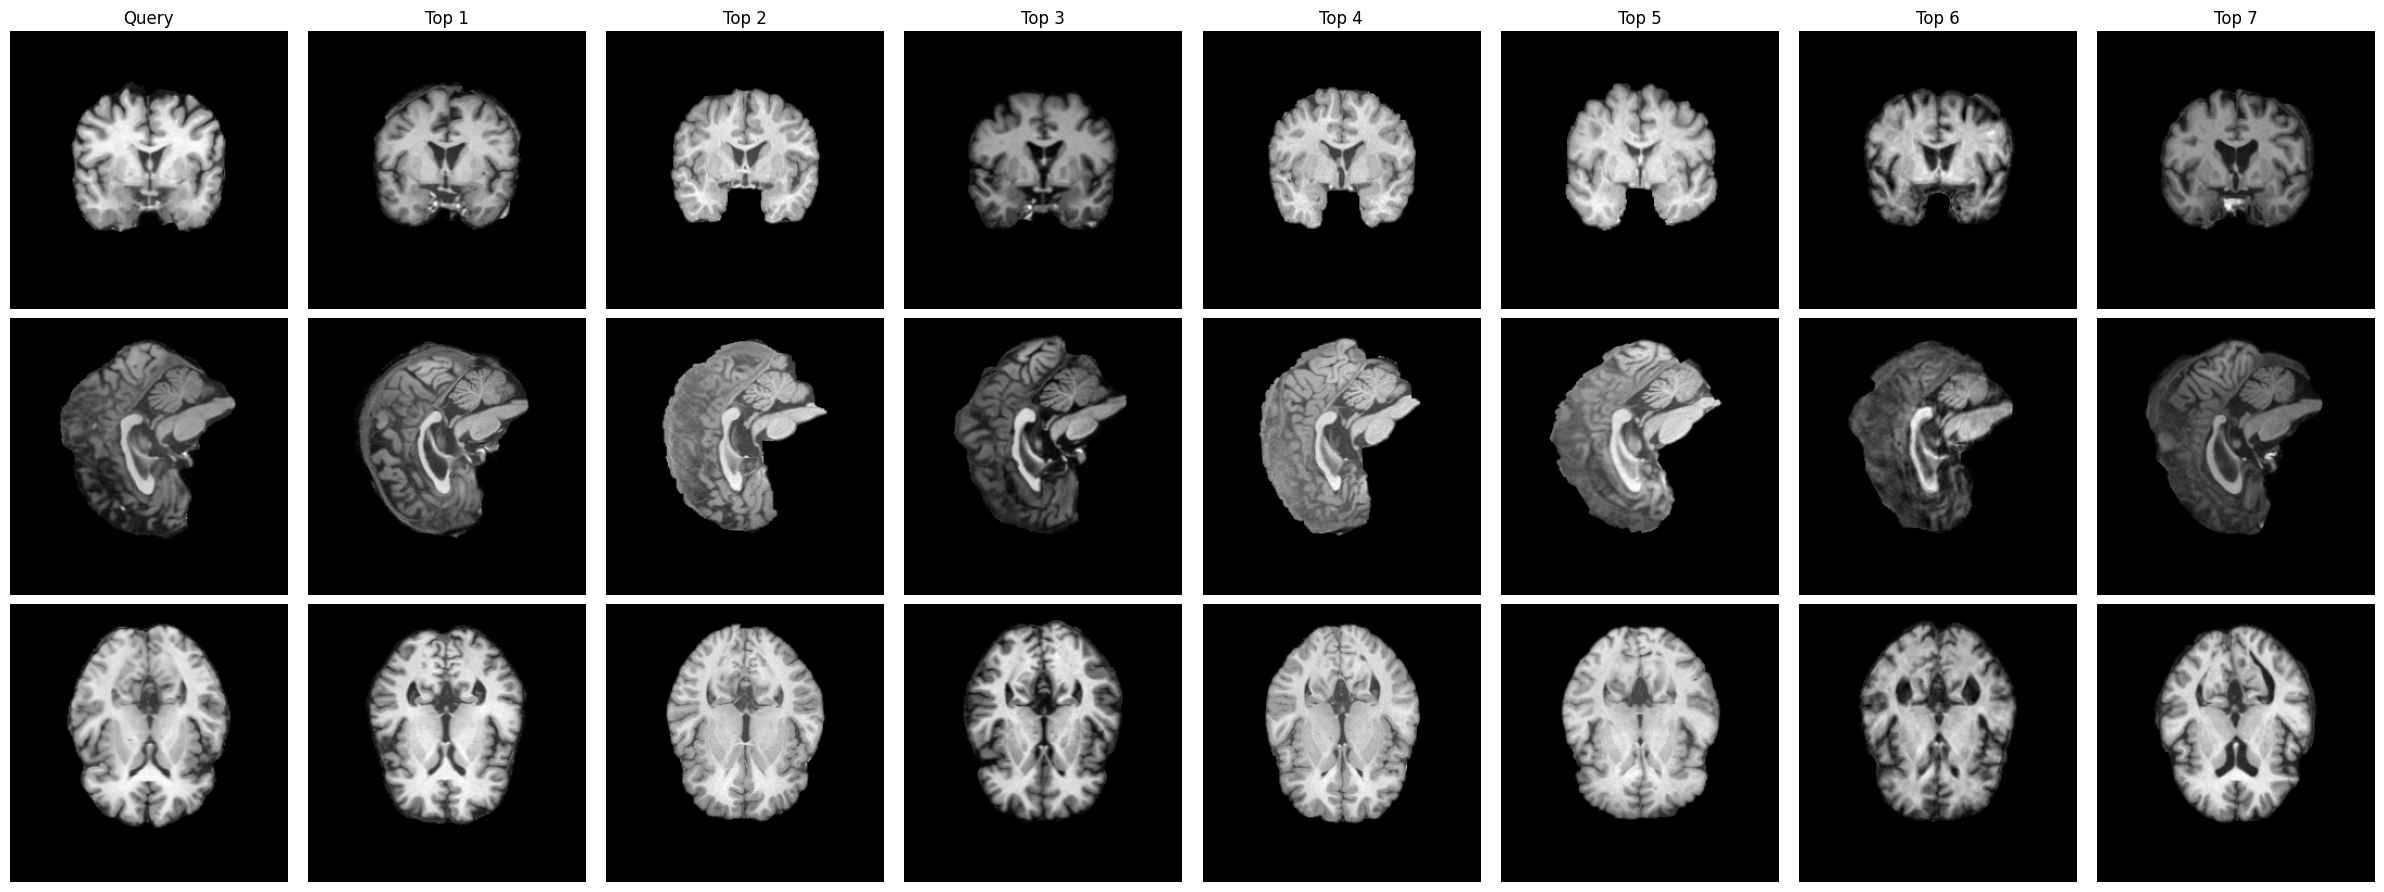

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_path = "/home/maia-user/cifs/Datasets/"

def plot_topk_brains(query_guid, topk, clinical_ds, retrieval_wb):
    """
    Plots axial, sagittal, coronal slices for:
    - the query brain
    - the top-k most similar retrieved brains
    """
    print(f"Plotting top-{topk} brains for query: {query_guid}")

    # --- Locate the query row from the retrieval table ---
    row = retrieval_wb[retrieval_wb["query"] == query_guid].iloc[0]
    top_ids = [row[f"top{i+1}"] for i in range(topk)]

    # --- Collect paths for query + retrieved samples ---
    all_ids = [query_guid] + top_ids
    paths = []
    for sid in all_ids:
        p = clinical_ds.loc[clinical_ds["GUID"] == sid, "brain"].values[0]
        paths.append(os.path.join(data_path, p))

    # --- Helper to load slices ---
    def load_slices(path):
        img = nib.load(path)
        vol = img.get_fdata()
        
        cx, cy, cz = np.array(vol.shape) // 2

        axial = vol[:, :, cz]
        sagittal = vol[cx, :, :]
        coronal = vol[:, cy, :]

        return axial.T, sagittal.T, coronal.T

    # Load slices
    slices = [load_slices(p) for p in paths]

    # --- Plot ---
    fig, axes = plt.subplots(3, len(paths), figsize=(3 * len(paths), 9))

    titles = ["Query"] + [f"Top {i}" for i in range(1, len(paths))]

    for col, (axial, sagittal, coronal) in enumerate(slices):
        axes[0, col].imshow(axial, cmap="gray")
        axes[0, col].set_title(titles[col])
        axes[0, col].axis("off")

        axes[1, col].imshow(sagittal, cmap="gray")
        axes[1, col].axis("off")

        axes[2, col].imshow(coronal, cmap="gray")
        axes[2, col].axis("off")

    plt.tight_layout()
    plt.show()
    
query_guid=retrieval_rb.iloc[3].query
plot_topk_brains(
    query_guid=query_guid,
    topk=7,
    clinical_ds=clinical_ds,
    retrieval_wb=retrieval_rb
)